In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score,recall_score, precision_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('D:\\NTI\\SecondWeek\\Task2\\Titanic-Dataset.csv')

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [8]:
df['Age'] = df['Age'].fillna( df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [9]:
df.dropna(subset=['Embarked'], inplace=True)

In [10]:
df.duplicated().sum()

np.int64(118)

In [11]:
df.drop_duplicates(inplace=True)


<Axes: xlabel='Sex', ylabel='Survived'>

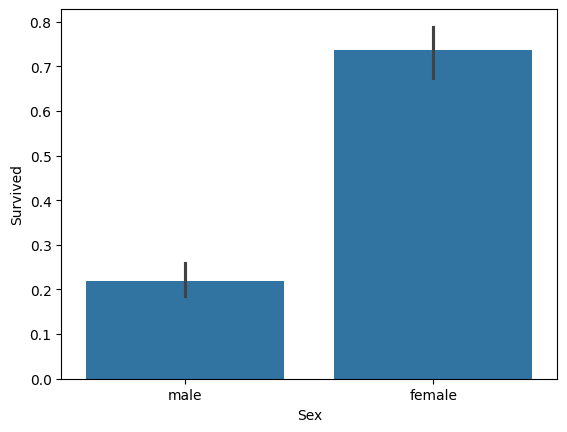

In [12]:
sns.barplot(x='Sex', y='Survived', data=df)

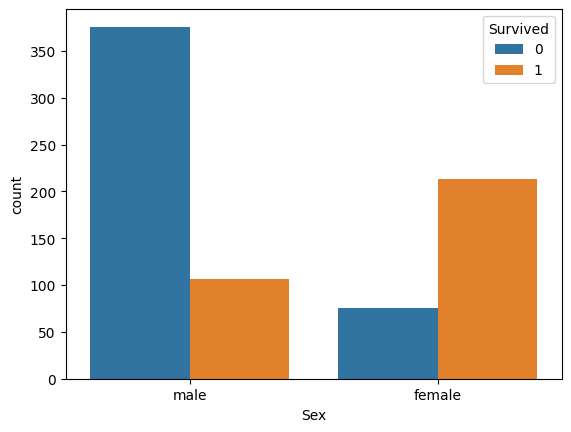

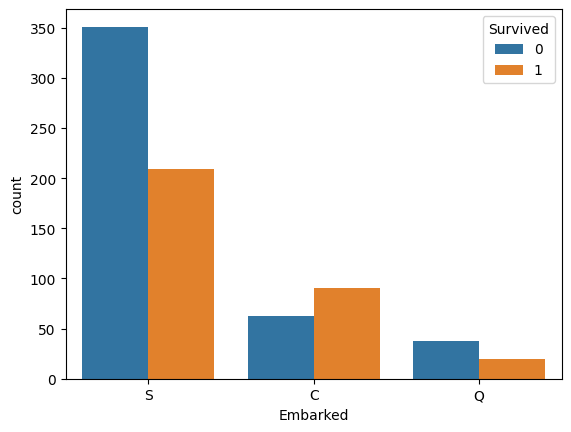

In [13]:
catcol = ['Sex', 'Embarked']

for col in catcol:
  sns.countplot(data=df,x=col,hue="Survived")
  plt.show()

In [14]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})


<Axes: >

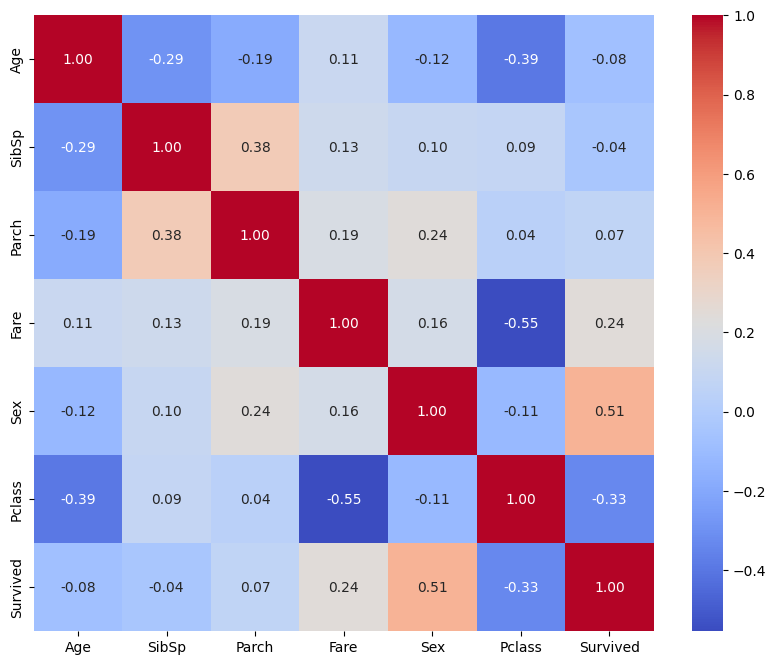

In [15]:
numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Pclass', 'Survived']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

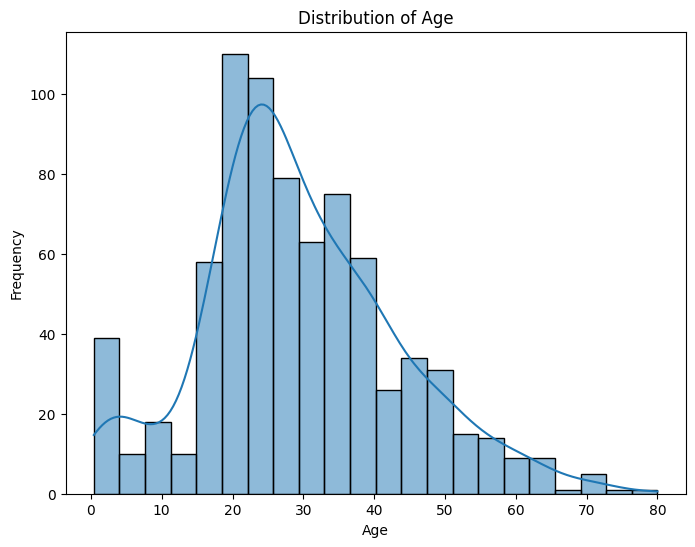

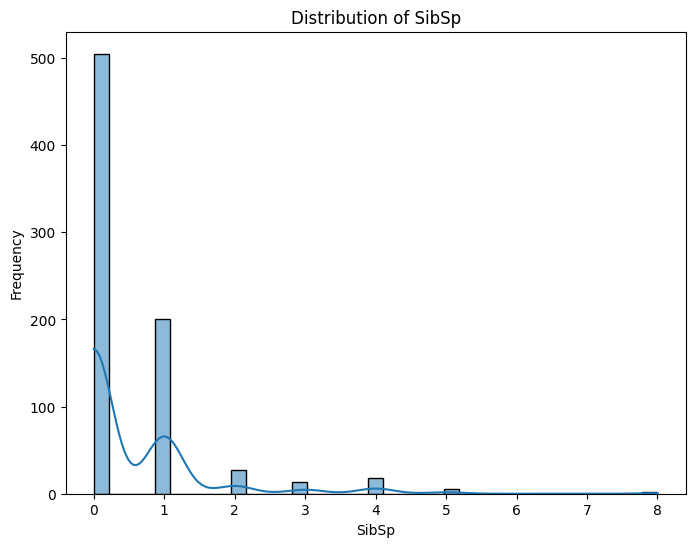

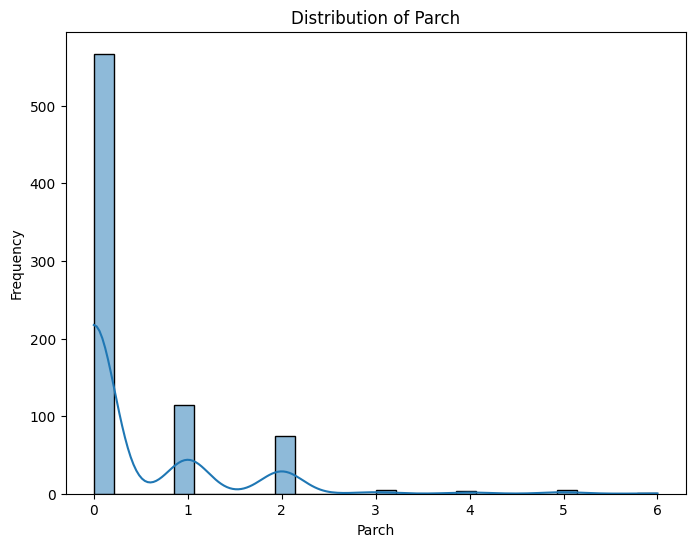

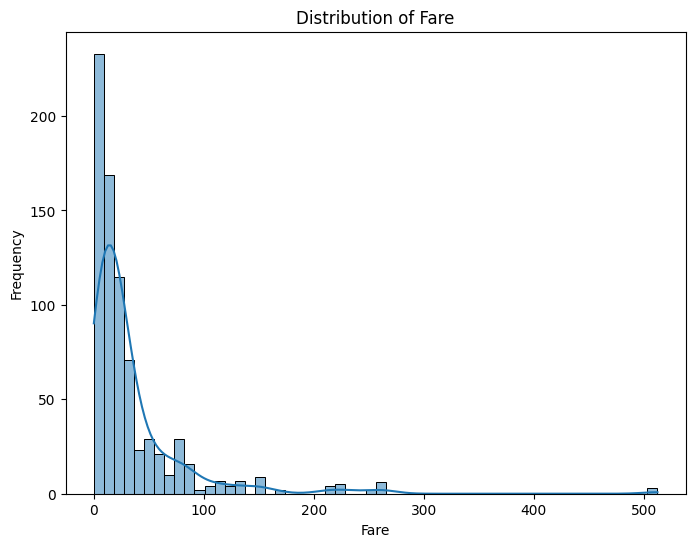

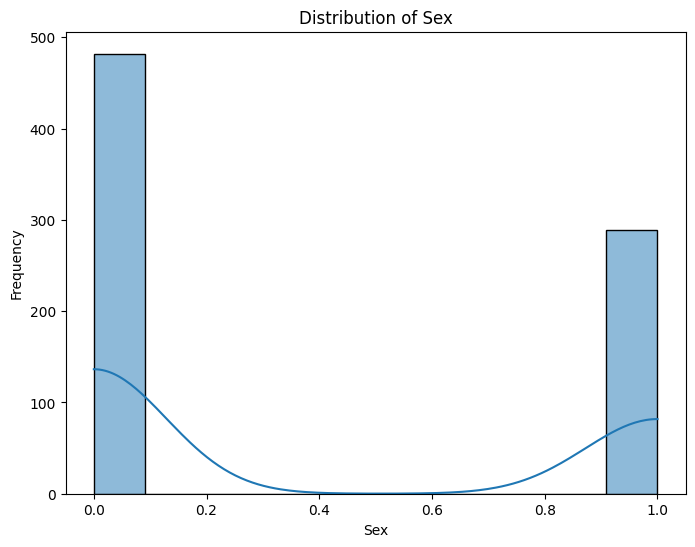

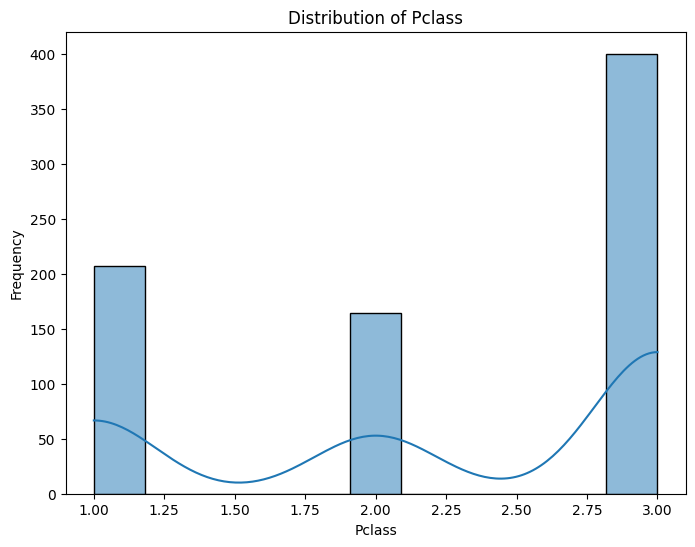

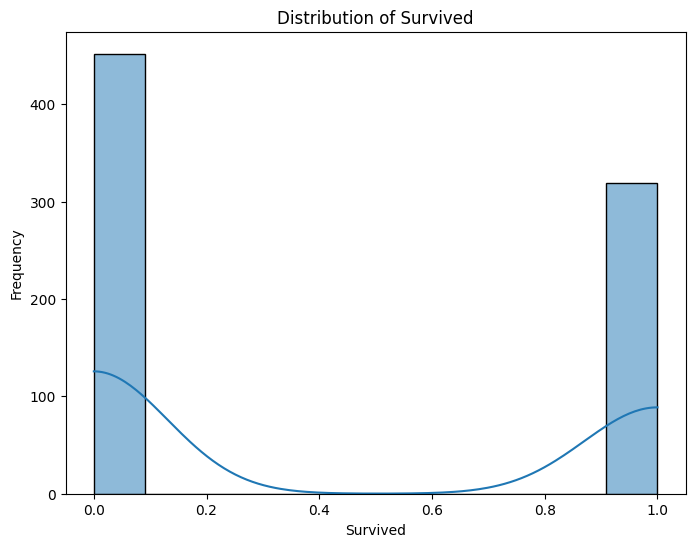

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [17]:
weak_features =  corr[corr <= 0.2]

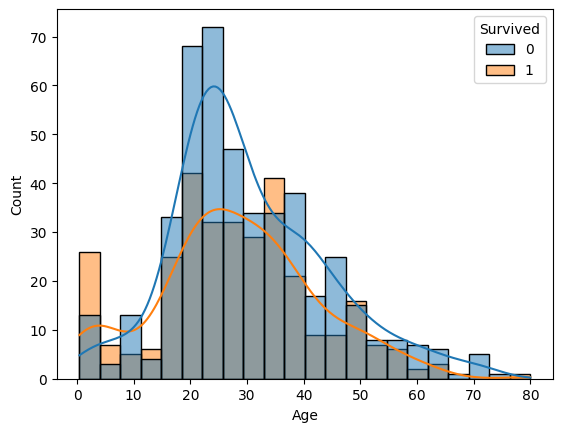

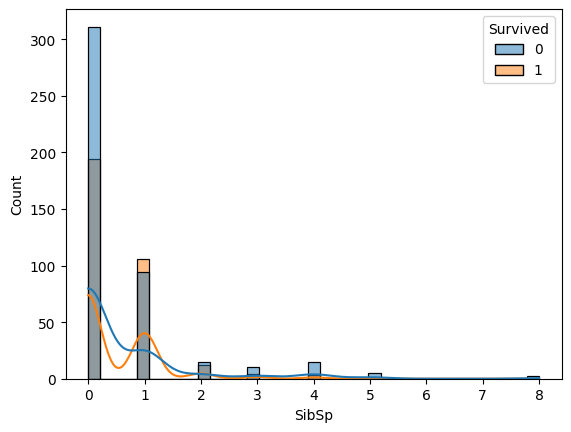

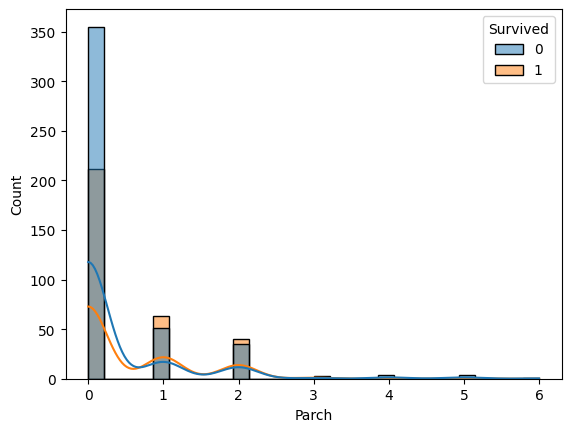

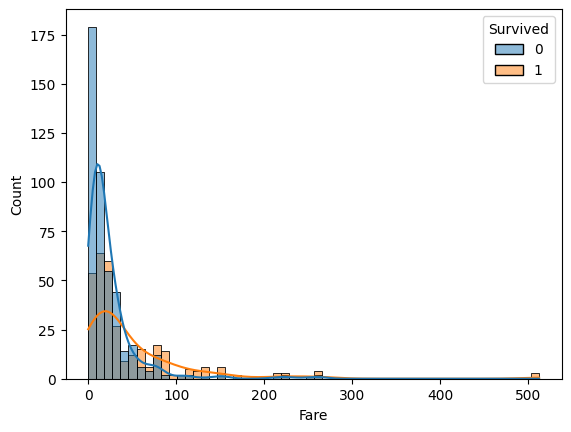

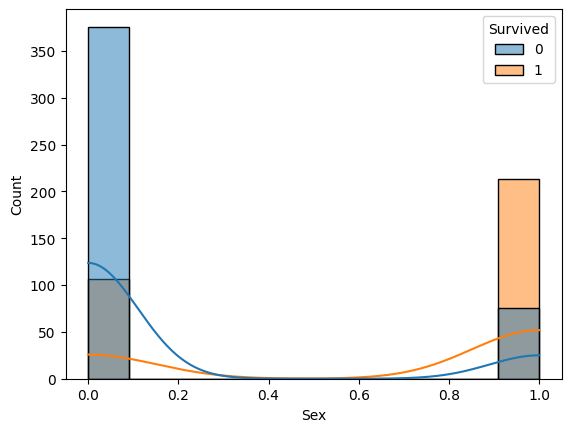

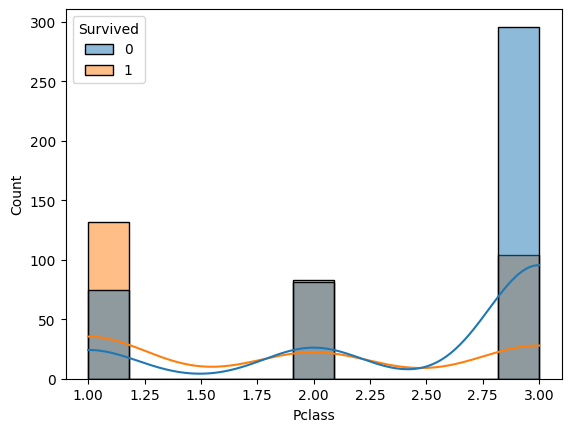

In [18]:
weak_features = corr[abs(corr) <= 0.2].index.tolist()

for col in weak_features:
    if col != 'Survived':
        sns.histplot(data=df, hue='Survived', x=col, kde=True)
        plt.show()

In [19]:
x = df.drop('Survived', axis=1)
y = df['Survived']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = [ 'Embarked']

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('robust', StandardScaler(), numeric_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ],
    remainder='passthrough'
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [23]:
def evaluate_model(model, x_test, y_test):

    y_pred = model.predict(x_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nAccuracy :", accuracy_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [24]:
models = {

    # =========================
    # Logistic Regression
    # =========================

    'Logistic Regression 1': LogisticRegression(
        C=1,
        solver='liblinear',
        random_state=42
    ),

    'Logistic Regression 2': LogisticRegression(
        C=0.1,
        solver='liblinear',
        random_state=42
    ),

    'Logistic Regression 3': LogisticRegression(
        C=10,
        solver='liblinear',
        random_state=42
    ),


    # =========================
    # Decision Tree
    # =========================

    'Decision Tree 1': DecisionTreeClassifier(
        criterion='gini',
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    'Decision Tree 2': DecisionTreeClassifier(
        criterion='entropy',
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ),

    'Decision Tree 3': DecisionTreeClassifier(
        criterion='entropy',
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ),


    # =========================
    # SVM
    # =========================

    'SVM 1': SVC(
        kernel='linear',
        C=1
    ),

    'SVM 2': SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    ),

    'SVM 3': SVC(
        kernel='poly',
        C=10,
        degree=3,
    ),


    # =========================
    # KNN
    # =========================

    'KNN 1': KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        metric='euclidean'
    ),

    'KNN 2': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='euclidean'
    )
}

In [25]:
for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(x_train_processed, y_train)

    print(f"Evaluating {model_name}...")

    evaluate_model(
        model,
        x_test_processed,
        y_test
    )

    print("\n" + "=" * 60 + "\n")

Training Logistic Regression 1...
Evaluating Logistic Regression 1...
Confusion Matrix:
[[83 12]
 [18 42]]

Accuracy : 0.8064516129032258
F1 Score : 0.7368421052631579
Recall   : 0.7
Precision: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        95
           1       0.78      0.70      0.74        60

    accuracy                           0.81       155
   macro avg       0.80      0.79      0.79       155
weighted avg       0.80      0.81      0.80       155



Training Logistic Regression 2...
Evaluating Logistic Regression 2...
Confusion Matrix:
[[85 10]
 [20 40]]

Accuracy : 0.8064516129032258
F1 Score : 0.7272727272727273
Recall   : 0.6666666666666666
Precision: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        95
           1       0.80      0.67      0.73        60

    accuracy                     